# Step 1: Cleaning
This dataset is the BRIGHTEN (V1 and V2) dataset. It is open-access from Synapse.org.

In [ ]:
import sys
import re
import os
import pandas as pd
import importlib
import time
import datetime as dt
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

############ LOAD in custom packages ################

project_root = os.path.join(os.getcwd(), "..") # Get path of the project 
sys.path.append(project_root) # Add project root to sys.path for script usage

# Import and reload (optional) custom scripts
from scripts import paths
from scripts import preprocessing as pre
from scripts import visualization as vis
from scripts import variables

importlib.reload(paths)
importlib.reload(pre)
importlib.reload(vis)
importlib.reload(variables)

# Filepaths
brighten_raw = paths.RAW
brighten_dir = paths.DATA

################ DEFINE column variables from data ###################
from scripts.variables import id_columns, df_names
from scripts.variables import all_cols, all_daily_cols, weekly_cols, baseline_cols, drop_weekly_cols
from scripts.variables import daily_cols_v1, daily_v2_sensor_hr, daily_v2_weather, daily_cols_v2, daily_v2_phone
from scripts.variables import gad_cols, phq9_base, alc_cols, phq9_cols, sleep_cols, gic_cols, sds_cols, phq2_cols

# Define label variables
aggregate_dfs = ['alldays_df','week_df']
# Update endings list if order changes
df_order_agg = ['raw_merged_df','merge_df','days_df', 'alldays_df']

target_vars = phq2_cols + phq9_cols
print('Run on:', dt.datetime.today().strftime('%a %d %b %Y, %I:%M%p'))



Run on: Sun 19 Apr 2026, 11:19AM


In [2]:
# test combining day function

def test_combine_day():
    data = {
        'num_id': [1]*4,
        'dt': pd.to_datetime(['2020-01-01 14:37:25', '2020-01-01 02:40:01', '2020-01-08 09:03:46', '2020-01-15 18:44:15']),
        'valueA': [2, 0, 0, 0],
        'valueB': ["0", "2", "2", "4"],
        'week': [1, 1, 2, 3]
    }
    df = pd.DataFrame(data)
    df['dt'] = pd.to_datetime(df['dt']) # take out time
    days_df = pre.combine_same_timeperiod(df,dt_col='dt')

    expected_valueA = [1, 0, 0] # averaging numerical variables
    expected_valueB = ["2", "2", "4"] # using last value for categorical variables

    assert days_df['valueA'].tolist() == expected_valueA, f"Expected {expected_valueA}, got {days_df['valueA'].tolist()}"
    assert days_df['valueB'].tolist() == expected_valueB, f"Expected {expected_valueB}, got {days_df['valueB'].tolist()}"

test_combine_day()

### Load in raw files

In [ ]:

############ LOAD in raw files  #############
print('Run on:', dt.datetime.today().strftime('%a %d %b %Y, %I:%M%p'))

# Raw files from https://www.synapse.org/Synapse:syn10848316/tables/ 


## These dfs only have baseline data
base_dfs = {}
base_dfs['phq9_baseline'] = pd.read_csv(os.path.join(brighten_raw,'PHQ-9 - Baseline.csv'))
base_dfs['demographics'] = pd.read_csv(os.path.join(brighten_raw,'Baseline Demographics.csv'))
base_dfs['mania'] = pd.read_csv(os.path.join(brighten_raw,'IMPACT Mania and Psychosis Screening.csv'))
base_dfs['alc'] = pd.read_csv(os.path.join(brighten_raw,'AUDIT-C.csv'))
base_dfs['gad'] = pd.read_csv(os.path.join(brighten_raw,'GAD - Anxiety.csv'))
base_dfs['mhs'] = pd.read_csv(os.path.join(brighten_raw,'Mental Health Services.csv'))

## These dfs have data which changes over time
raw_dfs = {}
raw_dfs['phq9'] = pd.read_csv(os.path.join(brighten_raw,'PHQ-9 - Depression.csv'))
raw_dfs['phq2'] = pd.read_csv(os.path.join(brighten_raw,'PHQ-2 - Depression.csv'))
raw_dfs['sds'] = pd.read_csv(os.path.join(brighten_raw,'SDS - Functional Impairment.csv'))
raw_dfs['sleep'] = pd.read_csv(os.path.join(brighten_raw,'Sleep Quality.csv'))
raw_dfs['gic'] = pd.read_csv(os.path.join(brighten_raw,'Patients Global Impression of Change Scale.csv'))
raw_dfs['phone_v1'] = pd.read_csv(os.path.join(brighten_raw,'Passive Features Brighten V1.csv'))
raw_dfs['phone_v2'] = pd.read_csv(os.path.join(brighten_raw,'Passive Phone Communication Features Brighten V2.csv'))
raw_dfs['weather_v2'] = pd.read_csv(os.path.join(brighten_raw,'Passive Weather Features Brighten V2.csv'))
raw_dfs['mobility_v2'] = pd.read_csv(os.path.join(brighten_raw,'Passive Mobility Features Brighten V2.csv'))
raw_dfs['cluster_v2'] = pd.read_csv(os.path.join(brighten_raw,'Passive Cluster Entries Brighten V2.csv'))




Run on: Fri 10 Apr 2026, 11:48AM


### Clean and update column names
Also creating some binary columns by categorizing numeric data

In [6]:
######### CLEANING AND UPDATING DATA ! #####################
print('Run on:', dt.datetime.today().strftime('%a %d %b %Y, %I:%M%p'))

index_variables = ['participant_id','week','day', 'dt', 'date', 'v']
drop_cols = ['ROW_ID','ROW_VERSION']
# Update column names
# dt.normalize() = strips the time component, setting everything to midnight.
    # Doing this because we want to combine data from the same days across surveys/metrics
    # So passive data, which is day-level but has no time, can be combined onto the same day as time-labelled surveys
# dt.tz_localize(None) = doesn't change the actual time values, just strips the timezone label-- fine because they all have EST or PST cohort name
for name, df in raw_dfs.items():
    df = df.drop([col for col in drop_cols if col in df.columns.to_list()], axis=1)
    if 'phq9Date' in df.columns:
        df['dt'] = (pd.to_datetime(df['phq9Date']))
        df = df.drop(['phq9Date'], axis=1)
    if 'phq2' in name:
        if 'dt_yesterday' in df.columns:
            df['dt'] = (pd.to_datetime(df['dt_yesterday']))
            df = df.drop(['dt_yesterday'], axis=1)
    if 'dt_passive' in df.columns:
        df['dt'] = (pd.to_datetime(df['dt_passive']))
        df = df.drop(['dt_passive'], axis=1)
    if 'dt_response' in df.columns:
        df['dt'] = (pd.to_datetime(df['dt_response']))
        df = df.drop(['dt_response'], axis=1)
    if 'time_in' in df.columns:
        df['dt'] = (pd.to_datetime(df['time_in']))
        df = df.drop(['time_in','time_out'], axis=1)
    if 'baselinePHQ9date' in df.columns:
        df['dt'] = (pd.to_datetime(df['baselinePHQ9date']))
        df = df.drop(['baselinePHQ9date'], axis=1)
    if 'startdate' in df.columns:
        df['dt'] = pd.to_datetime(df['startdate'], errors='coerce')
    if 'sum_phq9' in df.columns:
        df.rename(columns={'sum_phq9': 'phq9_sum'}, inplace=True)
        
    """Add version to each dataframe
    There were two parts to this study at different times with different data, 
    one where participant IDs start with "ENO", V2, and another where they start with colors (BLUE, YELLOW etc), V1"""
    df['v'] = np.where(df['participant_id'].str.contains('EN0'), 'V2','V1')

    """If demographic survey or baseline survey from onboarding week, add week = 0 & day = 0"""
    if name in ['alc', 'gad', 'mania', 'demo']:
        df['week'] = 0
        df['day'] = 0

    # Update the dfs dictionary with the modified DataFrame
    raw_dfs[name] = df


# Now make a 'date' column with normalized date
for name, df in raw_dfs.items():
    if 'dt' in df.columns:
        df['date'] = df['dt'].dt.tz_localize(None).dt.normalize()
        raw_dfs[name] = df
    
    print(name)
    display(df[[var for var in index_variables if var in df.columns]].head())



Run on: Fri 10 Apr 2026, 11:48AM
phq9


,participant_id,week,dt,date,v
0,BLUE-00048,1,2014-08-08,2014-08-08,V1
1,BLUE-00050,2,2014-08-23,2014-08-23,V1
2,BLUE-00050,3,2014-08-30,2014-08-30,V1
3,BLUE-00050,4,2014-09-08,2014-09-08,V1
4,BLUE-00050,6,2014-09-22,2014-09-22,V1


phq2


,participant_id,week,day,dt,date,v
0,BLUE-00048,3,0,2014-08-01 19:27:42+00:00,2014-08-01,V1
1,BLUE-00048,4,1,2014-08-02 15:13:09+00:00,2014-08-02,V1
2,BLUE-00048,4,2,2014-08-04 03:58:23+00:00,2014-08-04,V1
3,BLUE-00048,4,3,2014-08-04 16:53:04+00:00,2014-08-04,V1
4,BLUE-00048,4,6,2014-08-07 14:25:30+00:00,2014-08-07,V1


sds


...

,participant_id,dt,date,v
0,EN00033,2016-08-13,2016-08-13,V2
1,EN00033,2016-08-14,2016-08-14,V2
2,EN00033,2016-08-15,2016-08-15,V2
3,EN00033,2016-08-16,2016-08-16,V2
4,EN00033,2016-08-17,2016-08-17,V2


mobility_v2


,participant_id,week,dt,date,v
0,EN00538,0,2016-11-14,2016-11-14,V2
1,EN00538,0,2016-11-15,2016-11-15,V2
2,EN00538,0,2016-11-16,2016-11-16,V2
3,EN00538,0,2016-11-17,2016-11-17,V2
4,EN00538,0,2016-11-18,2016-11-18,V2


cluster_v2


,participant_id,week,dt,date,v
0,EN00033,0,2016-08-13 08:23:00,2016-08-13,V2
1,EN00033,0,2016-08-13 15:51:00,2016-08-13,V2
2,EN00033,0,2016-08-13 23:36:00,2016-08-13,V2
3,EN00033,0,2016-08-14 00:00:00,2016-08-14,V2
4,EN00033,0,2016-08-14 19:43:00,2016-08-14,V2


In [7]:
#### create binary and category variables
print('Run on:', dt.datetime.today().strftime('%a %d %b %Y, %I:%M%p'))

raw_dfs['phq9']['phq9_cat'] = raw_dfs['phq9']['phq9_sum'].apply(pre.cat_phq9)
raw_dfs['phq9']['phq9_bin'] = raw_dfs['phq9']['phq9_sum'].apply(pre.bin_phq9)
raw_dfs['phq2']['phq2_bin'] = raw_dfs['phq2']['phq2_sum'].apply(pre.bin_phq2)



Run on: Fri 10 Apr 2026, 11:48AM


In [8]:
# Investigate if there are any rows where there are multiple entries on the same day (dt)-- which are NOT complete duplicates
print('Run on:', dt.datetime.today().strftime('%a %d %b %Y, %I:%M%p'))

count=0
multiple_entries_one_day={}

for name, df in raw_dfs.items():
    print(name)
    multiple_entries_one_day[name]={}
    df_clean=df.drop_duplicates()
    if 'dt' in df_clean.columns:
        for i, (key, sub_day_df) in enumerate(df_clean.groupby(['participant_id', 'date'])):
            sub_day_df = sub_day_df.drop_duplicates()
            if sub_day_df.shape[0] > 1:
                pid = sub_day_df['participant_id'].iloc[0]
                multiple_entries_one_day[name][pid] = sub_day_df[['participant_id','week','dt','date']+[col for col in sub_day_df.columns if col not in ['participant_id','week','dt','date']]]
                


                


Run on: Fri 10 Apr 2026, 11:48AM
phq9
phq2
sds
sleep
gic
phone_v1
phone_v2
weather_v2
mobility_v2
cluster_v2


In [9]:
print(f'Run on: {dt.datetime.today().strftime('%a %d %b %Y, %I:%M%p')}\n')

for name, df in raw_dfs.items():
    print(f'\nin {name}, there are {len(multiple_entries_one_day[name].keys())} PIDs with > 1 non-duplicate entry per day')
    avg_daysets_per_pid = np.mean([len(v) for v in multiple_entries_one_day[name].values()])
    total_daysets = np.sum([len(v) for v in multiple_entries_one_day[name].values()])
    print(f'there are {total_daysets} instances of non-duplicate multi-entry days')
    #print(f'there are an average of {avg_daysets_per_pid} multi-entry days per person listed')

       

Run on: Fri 10 Apr 2026, 11:49AM


in phq9, there are 5 PIDs with > 1 non-duplicate entry per day
there are 10 instances of non-duplicate multi-entry days

in phq2, there are 690 PIDs with > 1 non-duplicate entry per day
there are 1384 instances of non-duplicate multi-entry days

in sds, there are 3 PIDs with > 1 non-duplicate entry per day
there are 6 instances of non-duplicate multi-entry days

in sleep, there are 0 PIDs with > 1 non-duplicate entry per day
there are 0.0 instances of non-duplicate multi-entry days

in gic, there are 0 PIDs with > 1 non-duplicate entry per day
there are 0.0 instances of non-duplicate multi-entry days

in phone_v1, there are 0 PIDs with > 1 non-duplicate entry per day
there are 0.0 instances of non-duplicate multi-entry days

in phone_v2, there are 0 PIDs with > 1 non-duplicate entry per day
there are 0.0 instances of non-duplicate multi-entry days

in weather_v2, there are 0 PIDs with > 1 non-duplicate entry per day
there are 0.0 instances of non-dupl

/Users/klj9278/miniconda3/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:3904: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/Users/klj9278/miniconda3/lib/python3.13/site-packages/numpy/_core/_methods.py:147: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


# There are, so let's combine those into one day

In [10]:
print(f'Run on: {dt.datetime.today().strftime('%a %d %b %Y, %I:%M%p')}\n')

days_dfs = {}
for name, df in raw_dfs.items():

    ########## Combine rows from the same day ###############
    day_df = pre.combine_same_timeperiod(df, id_col='participant_id',combine_on_col='date',dt_col='dt')
    day_df[f'dt_{name}'] = day_df['dt']
    day_df = day_df.drop(columns='dt') # This is so the individual/unique times of each dt for diff clusters is there, but we're still merging on the 'date' 
    days_dfs[name] = day_df
    



    ## Note: 
    # aggregation does a mean of all numeric entries, adn takes 'last' of any non-numeric 
    # so duplicates become the same, multiple numbers reported over the day => averaged
    # NOTE future dev: investigate if there's a way to tell accidental reportings/stopped early, to exclude those? 
    # dt becomes a list of all the dts when combined. so date is singular/merged on, 
    #  if there are 2 rows, one says 1/2/25 8:05am and the second says 1/2/25 10:03pm, 
    # the dt column becomes "1/2/25 8:05am, 1/2/25 10:03pm"



Run on: Fri 10 Apr 2026, 11:49AM



In [11]:
# Now lets check it worked
# If there are any with >1 per day
for name, df in days_dfs.items():
    print(name)
    if 'date' in df.columns:
        for i, (key, sub_day_df) in enumerate(df.groupby(['participant_id', 'date'])):
            if sub_day_df.shape[0] > 1:
                sub_day_df = sub_day_df.dropna(axis=1)
                display(sub_day_df)


phq9
phq2
sds
sleep
gic
phone_v1
phone_v2
weather_v2
mobility_v2
cluster_v2


In [12]:
print(f'Run on: {dt.datetime.today().strftime('%a %d %b %Y, %I:%M%p')}\n')

display(days_dfs['cluster_v2'])



Run on: Fri 10 Apr 2026, 11:49AM



,participant_id,week,cid,category,subcategories,v,date,dt_cluster_v2
0,EN00033,0.0,home,home,home,V2,2016-08-13,"2016-08-13 08:23:00, 2016-08-13 15:51:00, 2016..."
1,EN00033,0.0,home,home,home,V2,2016-08-14,"2016-08-14 00:00:00, 2016-08-14 19:43:00, 2016..."
2,EN00033,0.0,home,home,home,V2,2016-08-15,2016-08-15
3,EN00033,0.0,home,home,home,V2,2016-08-16,"2016-08-16 10:26:00, 2016-08-16 18:07:00"
4,EN00033,0.0,home,home,home,V2,2016-08-17,"2016-08-17 09:20:00, 2016-08-17 10:04:00, 2016..."
...,...,...,...,...,...,...,...,...
17546,ES05073,8.0,home,home,home,V1,2017-03-17,"2017-03-17 00:00:00, 2017-03-17 18:17:00"
17547,ES05073,8.0,home,home,home,V1,2017-03-18,"2017-03-18 00:00:00, 2017-03-18 14:52:00, 2017..."
17548,ES05073,8.0,home,home,home,V1,2017-03-20,"2017-03-20 09:55:00, 2017-03-20 16:12:00"
17549,ES05073,8.0,xNot,none,none,V1,2017-03-21,2017-03-21 16:05:00


### Merge together all the DFs into a large DF on the ID columns


In [13]:
### Create merge df 
print(f'Run on: {dt.datetime.today().strftime('%a %d %b %Y, %I:%M%p')}\n')

# Merging based on consistent columns-- so there shouldn't be any discrepancy 
# even if the week/dt is wrong, it will just create a new row for that dt if necessary
raw_merged_df = pd.DataFrame()

for name, df in days_dfs.items():
    # skip cluster_v2 because averaging it over day doesn't make sense
    # NOTE to create a measure for cluster_v2 where it's % of time at home/work/other or lengths or something
    if 'cluster_v2' in name: 
        continue  
    print(f'for df: {name}')
    if raw_merged_df.empty:
        raw_merged_df = df.copy()  # Start with the first valid DataFrame
        print(f'Merged in {name}')
    else:
        consistent_columns = [var for var in df.columns if var in raw_merged_df.columns]
        new_columns = [col for col in df.columns if col not in consistent_columns]
        raw_merged_df = pd.merge(raw_merged_df, df, on=consistent_columns, how='outer')
        print(f'Merged in {name} on {consistent_columns}. \n New columns: {new_columns}')
        print(raw_merged_df.shape)


if any('_x' in col or '_y' in col for col in raw_merged_df.columns):
    pattern = r'_x$|_y$'  # match column names that END in _x or _y
    matches = [col for col in raw_merged_df.columns if re.search(pattern, col)]
    print('Error: duplicated column with _x or _y', matches)
    


# Save raw_merged_df to cds
raw_merged_df['date'] = pd.to_datetime(raw_merged_df['date'], errors='coerce')
# Now sort by id, week and dt, so it should be obvious if any dt's are in the wrong week
raw_merged_df = raw_merged_df.sort_values(by=['participant_id', 'week', 'date'])
display(raw_merged_df.head())
raw_merged_df.to_csv(os.path.join(brighten_dir, 'raw_merged_df.csv'), index=False)
print('Saved raw_merged_df to raw_merged_df.csv')



Run on: Fri 10 Apr 2026, 11:49AM

for df: phq9
Merged in phq9
for df: phq2
Merged in phq2 on ['participant_id', 'week', 'v', 'date']. 
 New columns: ['day', 'phq2_1', 'phq2_2', 'phq2_sum', 'phq2_bin', 'dt_phq2']
(48489, 23)
for df: sds
Merged in sds on ['participant_id', 'week', 'v', 'date']. 
 New columns: ['sds_1', 'sds_2', 'sds_3', 'stress', 'support', 'dt_sds']
(49316, 29)
for df: sleep
Merged in sleep on ['participant_id', 'week', 'v', 'date']. 
 New columns: ['sleep_1', 'sleep_2', 'sleep_3', 'dt_sleep']
(49355, 33)
for df: gic
Merged in gic on ['participant_id', 'week', 'v', 'date']. 
 New columns: ['mood_1', 'dt_gic']
(49378, 35)
for df: phone_v1
Merged in phone_v1 on ['participant_id', 'day', 'week', 'v', 'date']. 
 New columns: ['cohort', 'user_phone_type', 'aggregate_communication', 'call_count', 'call_duration', 'interaction_diversity', 'missed_interactions', 'mobility', 'mobility_radius', 'sms_count', 'sms_length', 'unreturned_calls', 'dt_phone_v1']
(83373, 48)
for df: phon

,participant_id,week,phq9_sum,phq9_1,phq9_2,phq9_3,phq9_4,phq9_5,phq9_6,phq9_7,...,hours_accounted_for,hours_active,hours_high_speed_transportation,hours_of_sleep,hours_powered_vehicle,hours_stationary,hours_stationary_nhw,hours_walking,location_variance,dt_mobility_v2
0,BLUE-00037,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,BLUE-00037,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,BLUE-00037,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,BLUE-00037,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,BLUE-00037,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Saved raw_merged_df to raw_merged_df.csv


In [27]:
raw_merged_df=pd.read_csv(os.path.join(brighten_dir, 'raw_merged_df.csv'))
count = 0
for (pid, date), sub_day_df in raw_merged_df.groupby(['participant_id', 'date']):
    if len(sub_day_df) > 1:
        count += 1
print("Total duplicates:", count)

/var/folders/hw/bbf5fg0s5md12mjn50bptvhh0000gq/T/ipykernel_84006/994018745.py:1: DtypeWarning: Columns (35,36,47,64,82,97) have mixed types. Specify dtype option on import or set low_memory=False.
  raw_merged_df=pd.read_csv(os.path.join(brighten_dir, 'raw_merged_df.csv'))


Total duplicates: 41754


In [28]:
print(f'Run on: {dt.datetime.today().strftime('%a %d %b %Y, %I:%M%p')}\n')
raw_merged_df=pd.read_csv(os.path.join(brighten_dir, 'raw_merged_df.csv'))

########## Combine rows from the same day ###############
day_df = pre.combine_same_timeperiod(raw_merged_df, id_col='participant_id',combine_on_col='date')
day_df.to_csv(os.path.join(brighten_dir, 'raw_mergedDays_df.csv'), index=False)

count = 0
for (pid, date), sub_day_df in day_df.groupby(['participant_id', 'date']):
    if len(sub_day_df) > 1:
        count += 1
print("Total duplicates:", count)

Run on: Fri 10 Apr 2026, 01:40PM



/var/folders/hw/bbf5fg0s5md12mjn50bptvhh0000gq/T/ipykernel_84006/2097372765.py:2: DtypeWarning: Columns (35,36,47,64,82,97) have mixed types. Specify dtype option on import or set low_memory=False.
  raw_merged_df=pd.read_csv(os.path.join(brighten_dir, 'raw_merged_df.csv'))


Total duplicates: 0


### Preprocessing the Daily DF 
- Combining rows from the same day, by averaging over the day or using bfill and ffill
- Reindexing the data to include all possible days, since only days with data are currently shown (this will allow us to impute data over missing days, and see how many dayss are missing)

In [29]:
# test combining day function
print(f'Run on: {dt.datetime.today().strftime('%a %d %b %Y, %I:%M%p')}\n')

def test_combine_day():
    data = {
        'num_id': [1]*4,
        'dt': pd.to_datetime(['2020-01-01 14:37:25', '2020-01-01 02:40:01', '2020-01-08 09:03:46', '2020-01-15 18:44:15']),
        'valueA': [2, 0, 0, 0],
        'valueB': ["0", "2", "2", "4"],
        'week': [1, 1, 2, 3]
    }
    df = pd.DataFrame(data)
    df['dt'] = pd.to_datetime(df['dt'])
    days_df = pre.combine_same_timeperiod(df,dt_col='dt')

    expected_valueA = [1, 0, 0] # averaging numerical variables
    expected_valueB = ["2", "2", "4"] # using last value for categorical variables

    assert days_df['valueA'].tolist() == expected_valueA, f"Expected {expected_valueA}, got {days_df['valueA'].tolist()}"
    assert days_df['valueB'].tolist() == expected_valueB, f"Expected {expected_valueB}, got {days_df['valueB'].tolist()}"

test_combine_day()

Run on: Fri 10 Apr 2026, 01:40PM



In [32]:
print(f'Run on: {dt.datetime.today().strftime('%a %d %b %Y, %I:%M%p')}\n')

def test_reindex():
    data = {
        "num_id": pd.to_numeric([1,1,1,2,2,3,3,3]),
        "dt": pd.to_datetime([
            "2020-01-01", "2020-01-03", "2020-01-06",
            "2020-01-01", "2020-01-02",
            "2020-01-06","2020-01-09","2020-01-09"
        ], format='%Y-%m-%d'),
        "valueA": [2, 0, 0, 1, 2, 1, 2, 3],
        "valueB": ["2", "2", "4", "4", None, None, None, None],
    }
    df = pd.DataFrame(data)

    # --- 1. Test combine_same_day ---
    days_df = pre.combine_same_timeperiod(df, dt_col='dt',combine_on_col='dt')
    display(days_df)


    # for num_id=3, dt=2020-01-09 has duplicates (2 and 3)
    # so valueA should average to 2.5, valueB keep first ("2" if ordering is stable)
    expected_days = pd.DataFrame({
        "num_id": pd.to_numeric([1,1,1,2,2,3,3]),
        "dt": pd.to_datetime([
            "2020-01-01", "2020-01-03", "2020-01-06",
            "2020-01-01", "2020-01-02",
            "2020-01-06","2020-01-09"
        ], format='%Y-%m-%d'),
        "valueA": [2,0,0,1,2,1,2.5],
        "valueB": ["2","2","4","4",None,None,"2"]
    })

    
    assert (
    days_df["dt"].tolist() == expected_days["dt"].tolist()
    )
    

    # # --- 2. Test reindex_to_all_days ---
    

    # all_days_df = pre.reindex_to_all_days(days_df)

    # expected_dt = pd.date_range("2020-01-01", "2020-01-09", freq="D")
    # # check that each num_id has continuous daily rows
    # for pid in all_days_df["num_id"].unique():
    #     sub = all_days_df.loc[all_days_df["num_id"]==pid, "dt"]
    #     assert sub.tolist() == expected_dt[(expected_dt>=sub.min()) & (expected_dt<=sub.max())].tolist(), \
    #         f"Participant {pid} dates not continuous: {sub}"

    # print("✅ test_reindex passed")

test_reindex()

Run on: Fri 10 Apr 2026, 01:41PM



,num_id,valueA,valueB,dt
0,1,2.0,2,2020-01-01
1,1,0.0,2,2020-01-03
2,1,0.0,4,2020-01-06
3,2,1.0,4,2020-01-01
4,2,2.0,None,2020-01-02
5,3,1.0,None,2020-01-06
6,3,2.5,None,"2020-01-09, 2020-01-09"


AssertionError: 

In [ ]:
############ Reindex to alldays_df & add indicators ##########
print(f'Run on: {dt.datetime.today().strftime('%a %d %b %Y, %I:%M%p')}\n')

## days_df -> _alldays, reindexing each range of dates for a participant to include all dates in that range
importlib.reload(pre)

raw_merged_df_demo=pd.read_csv(os.path.join(brighten_dir, 'raw_mergedDays_df.csv'))
alldays_df = pre.reindex_to_all_days(raw_merged_df_demo, id_col='participant_id')


### Add Demographic Columns
demo_df = pd.read_csv(os.path.join(brighten_dir, f'demographics_clean.csv'))
consistent_columns = [var for var in demo_df.columns if var in alldays_df.columns]
print(f'Found consistent columns: {consistent_columns}')
alldays_df = pd.merge(alldays_df, demo_df, on=consistent_columns, how='outer')
alldays_df.to_csv(os.path.join(brighten_dir, 'alldays_df_demo.csv'), index=False)
print('Saved alldays_df_demo to BRIGHTEN dir')
print(f'Shape of alldays_demo = {alldays_df.shape}')



# Save correct day for each sub
sub_day = pd.DataFrame()
baseline_cols_present = [col for col in alldays_df.columns if col in demo_df.columns]
for sub, sub_df in alldays_df.groupby('participant_id', as_index=False):
    sub_df = sub_df.sort_values(by='date')
    sub_df = sub_df.reset_index(drop=True)
    sub_df = sub_df.drop(columns='day')
    sub_df = sub_df.reset_index(names='day')

    ## Add week
    sub_df['week'] = sub_df['day'] // 7

    ## Add id_day, which allows multilevel grouping by participant-day ########
    sub_df['id_day'] = sub_df['participant_id'].astype(str) +'_'+ sub_df['day'].astype(str)
    sub_df['id_week'] = sub_df['participant_id'].astype(str) +'_'+ sub_df['week'].astype(str)


    ## Make sure base cols are filled
    sub_df[baseline_cols_present] = (
        sub_df[baseline_cols_present]
        .bfill()
        .ffill()
        .infer_objects(copy=False)
    )    
    sub_day = pd.concat([sub_day, sub_df])



print(f'Shape of sub_day is = {sub_day.shape}')

if not 'id_day' in id_columns:
    id_columns.append('id_day')
    print(id_columns)


## Add weekday
sub_day['day_of_week'] = sub_day['date'].dt.weekday + 1
sub_day['month'] = sub_day['date'].dt.month
## Add season
seasons = {
    'fall': [9, 10, 11],
    'winter': [12, 1, 2],
    'spring': [3, 4, 5],
    'summer': [6, 7, 8]
}

# Assign season labels (strings)
for season, months in seasons.items():
    sub_day.loc[sub_day['month'].isin(months), 'season'] = season

# Encode seasons numerically
season_mapping = {season: i + 1 for i, season in enumerate(seasons.keys())}
sub_day['season_num'] = sub_day['season'].map(season_mapping)

## Save alldays_df
sub_day.to_csv(os.path.join(brighten_dir, 'sub_day_demo.csv'), index=False)
print(f'Saved sub_day_demo.csv to brighten_dir, shape: {alldays_df.shape}')

## Save encoder mapping
season_encoder_df = pd.DataFrame(
    list(season_mapping.items()), columns=['season', 'season_num']
)
season_encoder_df.to_csv(os.path.join(brighten_dir, 'season_encoder_key.csv'), index=False)
print("Saved season_encoder_key.csv")



Run on: Fri 10 Apr 2026, 11:57AM



/var/folders/hw/bbf5fg0s5md12mjn50bptvhh0000gq/T/ipykernel_84006/686860335.py:7: DtypeWarning: Columns (35,36,47,64,82,97) have mixed types. Specify dtype option on import or set low_memory=False.
  raw_merged_df_demo=pd.read_csv(os.path.join(brighten_dir, 'raw_mergedDays_df.csv'))


Found consistent columns: ['participant_id']
Saved alldays_df_demo to BRIGHTEN dir
Shape of alldays_demo = (110903, 122)


/var/folders/hw/bbf5fg0s5md12mjn50bptvhh0000gq/T/ipykernel_84006/686860335.py:42: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .bfill()
/var/folders/hw/bbf5fg0s5md12mjn50bptvhh0000gq/T/ipykernel_84006/686860335.py:42: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .bfill()
/var/folders/hw/bbf5fg0s5md12mjn50bptvhh0000gq/T/ipykernel_84006/686860335.py:42: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior

Shape of sub_day = (110903, 124)
Saved sub_day_demo.csv to brighten_dir, shape: (110903, 122)
Saved season_encoder_key.csv


In [ ]:
###########  Save as V1 and V2 ##############
print(f'Run on: {dt.datetime.today().strftime('%a %d %b %Y, %I:%M%p')}\n')

alldays_df = pd.read_csv(os.path.join(brighten_dir, 'sub_day_demo.csv'))

v1 = alldays_df[alldays_df['v']=='V1']
v1 = v1.drop(columns=daily_cols_v2)
v1.to_csv(os.path.join(brighten_dir, 'v1_day.csv'), index=False)
display(v1)
# print(v1.columns.to_list())

# Doing by hour for v2 because there's only 13% missingness for hours accounted for, 
# vs in V1 there's >99% missingness in hours accounted for
v2_non_hr = alldays_df[alldays_df['v']=='V2']
v2_non_hr = v2_non_hr.drop(columns=daily_cols_v1)
v2_non_hr.to_csv(os.path.join(brighten_dir, 'v2_non_hr.csv'), index=False)
display(v2_non_hr)
# print(v2_non_hr.columns.to_list())


Run on: Sun 19 Apr 2026, 11:21AM



/var/folders/hw/bbf5fg0s5md12mjn50bptvhh0000gq/T/ipykernel_20846/4090893659.py:4: DtypeWarning: Columns (17,22,28,32,34,35,36,47,64,82,97,111) have mixed types. Specify dtype option on import or set low_memory=False.
  alldays_df = pd.read_csv(os.path.join(brighten_dir, 'sub_day_demo.csv'))


,day,date,participant_id,week,phq9_sum,phq9_1,phq9_2,phq9_3,phq9_4,phq9_5,...,marital_status,race,age_category,num_id,id_day,id_week,day_of_week,month,season,season_num
0,0,2014-05-09,BLUE-00037,0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,BLUE-00037_0,BLUE-00037_0,5.0,5.0,spring,3.0
1,1,2014-05-10,BLUE-00037,0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,BLUE-00037_1,BLUE-00037_0,6.0,5.0,spring,3.0
2,2,2014-05-11,BLUE-00037,0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,BLUE-00037_2,BLUE-00037_0,7.0,5.0,spring,3.0
3,3,2014-05-12,BLUE-00037,0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,BLUE-00037_3,BLUE-00037_0,1.0,5.0,spring,3.0
4,4,2014-05-13,BLUE-00037,0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,BLUE-00037_4,BLUE-00037_0,2.0,5.0,spring,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
110898,83,2015-07-31,YELLOW-00317,11,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,YELLOW-00317_83,YELLOW-00317_11,5.0,7.0,summer,4.0
110899,84,2015-08-01,YELLOW-00317,12,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,YELLOW-00317_84,YELLOW-00317_12,6.0,8.0,summer,4.0
110900,85,2015-08-02,YELLOW-00317,12,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,YELLOW-00317_85,YELLOW-00317_12,7.0,8.0,summer,4.0
110901,86,2015-08-03,YELLOW-00317,12,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,YELLOW-00317_86,YELLOW-00317_12,1.0,8.0,summer,4.0


,day,date,participant_id,week,phq9_sum,phq9_1,phq9_2,phq9_3,phq9_4,phq9_5,...,marital_status,race,age_category,num_id,id_day,id_week,day_of_week,month,season,season_num
14295,0,2016-08-13,EN00033,0,NaN,NaN,NaN,NaN,NaN,NaN,...,1.0,6.0,3.0,153.0,EN00033_0,EN00033_0,6.0,8.0,summer,4.0
14296,1,2016-08-14,EN00033,0,NaN,NaN,NaN,NaN,NaN,NaN,...,1.0,6.0,3.0,153.0,EN00033_1,EN00033_0,7.0,8.0,summer,4.0
14297,2,2016-08-15,EN00033,0,NaN,NaN,NaN,NaN,NaN,NaN,...,1.0,6.0,3.0,153.0,EN00033_2,EN00033_0,1.0,8.0,summer,4.0
14298,3,2016-08-16,EN00033,0,NaN,NaN,NaN,NaN,NaN,NaN,...,1.0,6.0,3.0,153.0,EN00033_3,EN00033_0,2.0,8.0,summer,4.0
14299,4,2016-08-17,EN00033,0,NaN,NaN,NaN,NaN,NaN,NaN,...,1.0,6.0,3.0,153.0,EN00033_4,EN00033_0,3.0,8.0,summer,4.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
43280,33,2017-03-31,EN05370,4,NaN,NaN,NaN,NaN,NaN,NaN,...,2.0,3.0,1.0,1111.0,EN05370_33,EN05370_4,5.0,3.0,spring,3.0
43281,34,2017-04-01,EN05370,4,NaN,NaN,NaN,NaN,NaN,NaN,...,2.0,3.0,1.0,1111.0,EN05370_34,EN05370_4,6.0,4.0,spring,3.0
43282,35,2017-04-02,EN05370,5,NaN,NaN,NaN,NaN,NaN,NaN,...,2.0,3.0,1.0,1111.0,EN05370_35,EN05370_5,7.0,4.0,spring,3.0
43283,36,2017-04-03,EN05370,5,NaN,NaN,NaN,NaN,NaN,NaN,...,2.0,3.0,1.0,1111.0,EN05370_36,EN05370_5,1.0,4.0,spring,3.0


### Look at how many hours are accounted for 
For V2, each subject has a listing of how many hours the GPS accounts for. Thus we can use that to filter for participants who had at least a chunk of time accounted by GPS (6hrs or more), and then change distance measures into the average per hour. This way we can use all the data from the number of hours a GPS was tracking, while retaining comparability across subjects with different number of hours. This is a limitation of the first version of the study, where we don't know how much of the day a GPS sensor was on.
There is no evidence to suggest that the GPS accounting-for was based on user behavior, so we're treating these outages as random.


In [4]:
from scripts.variables import daily_v2_sensor
print(f'Run on: {dt.datetime.today().strftime('%a %d %b %Y, %I:%M%p')}\n')

# Look at how many hours accounted for
v2_non_hr = pd.read_csv(os.path.join(brighten_dir, 'v2_non_hr.csv'))

# Make all hours_accounted_for under 6hrs as np.nan
v2_hr = v2_non_hr.copy()
v2_hr['hours_accounted_for'] = v2_hr['hours_accounted_for'].mask(v2_hr['hours_accounted_for'] < 6)

# For V2, change distance into average over all hours accounted for
for col in daily_v2_sensor:
    if col in v2_non_hr.columns:
        if col!='came_to_work':   # drop because it's a boolean value  
            # This makes a col where if hours_accounted_for >= 6, now _avg has an average val/hour
            v2_hr[f'{col}_hr'] = (v2_hr[col].astype(float) / v2_hr['hours_accounted_for'].astype(float))
    else:
        print(f'{col} not found in df')
        
v2_hr.to_csv(os.path.join(brighten_dir, 'v2_day_raw.csv'), index=False)
print("Saved v2_day_raw.csv to brighten_dr")
display(v2_hr)

Run on: Sun 19 Apr 2026, 11:28AM



/var/folders/hw/bbf5fg0s5md12mjn50bptvhh0000gq/T/ipykernel_20846/489858926.py:5: DtypeWarning: Columns (54) have mixed types. Specify dtype option on import or set low_memory=False.
  v2_non_hr = pd.read_csv(os.path.join(brighten_dir, 'v2_non_hr.csv'))


Saved v2_day_raw.csv to brighten_dr


,day,date,participant_id,week,phq9_sum,phq9_1,phq9_2,phq9_3,phq9_4,phq9_5,...,season_num,distance_walking_hr,distance_active_hr,hours_active_hr,distance_powered_vehicle_hr,hours_powered_vehicle_hr,hours_high_speed_transportation_hr,distance_high_speed_transportation_hr,location_variance_hr,hours_of_sleep_hr
0,0,2016-08-13,EN00033,0,NaN,NaN,NaN,NaN,NaN,NaN,...,4.0,50.590909,81.690909,0.006091,10155.036364,0.195455,0.001545,526.772727,-0.103364,0.383364
1,1,2016-08-14,EN00033,0,NaN,NaN,NaN,NaN,NaN,NaN,...,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,2016-08-15,EN00033,0,NaN,NaN,NaN,NaN,NaN,NaN,...,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,2016-08-16,EN00033,0,NaN,NaN,NaN,NaN,NaN,NaN,...,4.0,263.558333,433.225000,0.068083,120.066667,0.001417,0.000000,0.000000,-0.284417,0.429167
4,4,2016-08-17,EN00033,0,NaN,NaN,NaN,NaN,NaN,NaN,...,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25011,33,2017-03-31,EN05370,4,NaN,NaN,NaN,NaN,NaN,NaN,...,3.0,108.316667,4506.716667,0.441667,4212.700000,0.119500,0.000000,0.000000,-0.382833,1.925000
25012,34,2017-04-01,EN05370,4,NaN,NaN,NaN,NaN,NaN,NaN,...,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25013,35,2017-04-02,EN05370,5,NaN,NaN,NaN,NaN,NaN,NaN,...,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25014,36,2017-04-03,EN05370,5,NaN,NaN,NaN,NaN,NaN,NaN,...,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Creating a Weekly DF
#### Averaging the numeric variables across each week

In [5]:
# Create a weekly version of the df 
print(f'Run on: {dt.datetime.today().strftime('%a %d %b %Y, %I:%M%p')}\n')

for v in ['v1','v2']:
    df = pd.read_csv(os.path.join(brighten_dir, f'{v}_day_raw.csv'))

    # Step 2: Define aggregation functions for numeric and non-numeric data
    aggregation_functions = {
        col: 'mean' if (pd.api.types.is_numeric_dtype(df[col]) and col not in ['week', 'day', 'dt','date']) else 'first'
        for col in df.columns if col not in ('id_day', 'id_week')  # Exclude id_columns from aggregation, use first value
    }

    # Step 3: Group by 'week' and apply the aggregation functions
    week_df = df.groupby('id_week').agg(aggregation_functions).reset_index()
    week_df = week_df.loc[:, ~week_df.columns.str.contains('^Unnamed')]

    # Step 4: Save df
    week_df.to_csv(os.path.join(brighten_dir, f'{v}_week_raw.csv'), index=False)
    print(f'Saved {v}_week_raw.csv to Brighten Dir {week_df.shape}')



Run on: Sun 19 Apr 2026, 11:29AM



/var/folders/hw/bbf5fg0s5md12mjn50bptvhh0000gq/T/ipykernel_20846/1342303736.py:5: DtypeWarning: Columns (17,22,28,32,34,35,36,47,48,49,54,68) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(os.path.join(brighten_dir, f'{v}_day_raw.csv'))


Saved v1_week_raw.csv to Brighten Dir (11804, 84)
Saved v2_week_raw.csv to Brighten Dir (4045, 126)


/var/folders/hw/bbf5fg0s5md12mjn50bptvhh0000gq/T/ipykernel_20846/1342303736.py:5: DtypeWarning: Columns (54) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(os.path.join(brighten_dir, f'{v}_day_raw.csv'))


In [6]:
for v in ['v1','v2']:
    week_df = pd.read_csv(os.path.join(brighten_dir, f'{v}_week_raw.csv'))
    print(v)
    display(week_df.head())


v1


/var/folders/hw/bbf5fg0s5md12mjn50bptvhh0000gq/T/ipykernel_20846/3606524046.py:2: DtypeWarning: Columns (49,50,55) have mixed types. Specify dtype option on import or set low_memory=False.
  week_df = pd.read_csv(os.path.join(brighten_dir, f'{v}_week_raw.csv'))


,id_week,day,date,participant_id,week,phq9_sum,phq9_1,phq9_2,phq9_3,phq9_4,...,income_satisfaction,income_lastyear,marital_status,race,age_category,num_id,day_of_week,month,season,season_num
0,BLUE-00037_0,0,2014-05-09,BLUE-00037,0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,4.00,5.0,spring,3.0
1,BLUE-00037_1,7,2014-05-16,BLUE-00037,1,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,4.50,5.0,spring,3.0
2,BLUE-00037_10,70,2014-07-18,BLUE-00037,10,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,3.25,7.0,summer,4.0
3,BLUE-00037_11,77,2014-07-25,BLUE-00037,11,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,5.00,7.0,summer,4.0
4,BLUE-00037_2,14,2014-05-23,BLUE-00037,2,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,4.00,5.0,spring,3.0


v2


,id_week,day,date,participant_id,week,phq9_sum,phq9_1,phq9_2,phq9_3,phq9_4,...,season_num,distance_walking_hr,distance_active_hr,hours_active_hr,distance_powered_vehicle_hr,hours_powered_vehicle_hr,hours_high_speed_transportation_hr,distance_high_speed_transportation_hr,location_variance_hr,hours_of_sleep_hr
0,EN00033_0,0,2016-08-13,EN00033,0,NaN,NaN,NaN,NaN,NaN,...,4.000000,157.074621,257.457955,0.037087,5137.551515,0.098436,0.000773,263.386364,-0.193890,0.406265
1,EN00033_1,7,2016-08-20,EN00033,1,NaN,NaN,NaN,NaN,NaN,...,4.000000,543.600609,1727.165864,0.168271,6224.989206,0.111671,0.000000,0.000000,-0.201521,0.807474
2,EN00033_2,14,2016-08-27,EN00033,2,NaN,NaN,NaN,NaN,NaN,...,3.142857,339.544444,670.888889,0.081444,0.000000,0.000000,0.000000,0.000000,-0.410667,0.572222
3,EN00033_3,21,2016-09-03,EN00033,3,NaN,NaN,NaN,NaN,NaN,...,1.000000,621.374000,2489.018929,0.188446,18964.589000,0.236189,0.000425,158.615000,-0.191066,0.631160
4,EN00033_4,28,2016-09-10,EN00033,4,NaN,NaN,NaN,NaN,NaN,...,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# Keep only subjects in weekly data that have 4 or more weeks of data for weekly
print(f'Run on: {dt.datetime.today().strftime('%a %d %b %Y, %I:%M%p')}\n')

for name in df_names:
        df = pd.read_csv(os.path.join(brighten_dir, f'{name}_raw.csv'))
        df = df.loc[:, ~df.columns.str.contains('^Unnamed')]
        subs=[]
        # Find each sub's max for each column
        for sub_df in df.groupby('num_id'):
            if sub_df[1]['week'].max() >= 4:
                subs.append(sub_df[0])    
            if sub_df[1].shape[0] >= 20:
                 subs.append(sub_df[0])
        df_subs = df[df['num_id'].isin(subs)]
        print(f'shape of {name} df {df.shape}, shape of df_subs (only those with >=4 weeks or >=20 days) {df_subs.shape}')

        df_subs.to_csv(os.path.join(brighten_dir, f'{name}_sufficientdata.csv'))
        df_subs=df_subs[[col for col in id_columns if col in df_subs.columns]+[col for col in df_subs.columns if col not in id_columns]]
        display(df_subs.head())
        print(f"Saved df_subs to {name}_sufficientdata.csv")

for name in df_names:
    df = pd.read_csv(os.path.join(brighten_dir, f'{name}_sufficientdata.csv'))
    df = df.loc[:, ~df.columns.str.contains('^Unnamed')]
    


Run on: Sun 12 Apr 2026, 10:42PM



/var/folders/hw/bbf5fg0s5md12mjn50bptvhh0000gq/T/ipykernel_46404/1907353352.py:5: DtypeWarning: Columns (17,22,28,32,34,35,36,47,48,49,54,68) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(os.path.join(brighten_dir, f'{name}_raw.csv'))


shape of v1_day df (74243, 85), shape of df_subs (only those with >=4 weeks or >=20 days) (61304, 85)


,num_id,date,month,week,day,id_week,id_day,v,season,day_of_week,...,bin_clin,gender,education,working,income_satisfaction,income_lastyear,marital_status,race,age_category,season_num
380,1.0,2014-08-01,8.0,0,0,BLUE-00049_0,BLUE-00049_0,V1,summer,5.0,...,0.0,1.0,2.0,0.0,3.0,6.0,0.0,2.0,3.0,4.0
381,1.0,2014-08-02,8.0,0,1,BLUE-00049_0,BLUE-00049_1,V1,summer,6.0,...,0.0,1.0,2.0,0.0,3.0,6.0,0.0,2.0,3.0,4.0
382,1.0,2014-08-03,8.0,0,2,BLUE-00049_0,BLUE-00049_2,V1,summer,7.0,...,0.0,1.0,2.0,0.0,3.0,6.0,0.0,2.0,3.0,4.0
383,1.0,2014-08-04,8.0,0,3,BLUE-00049_0,BLUE-00049_3,V1,summer,1.0,...,0.0,1.0,2.0,0.0,3.0,6.0,0.0,2.0,3.0,4.0
384,1.0,2014-08-05,8.0,0,4,BLUE-00049_0,BLUE-00049_4,V1,summer,2.0,...,0.0,1.0,2.0,0.0,3.0,6.0,0.0,2.0,3.0,4.0


Saved df_subs to v1_day_sufficientdata.csv
shape of v2_day df (25016, 127), shape of df_subs (only those with >=4 weeks or >=20 days) (23709, 127)


...

,num_id,date,month,week,day,id_week,v,season,day_of_week,cohort,...,bin_clin,gender,education,working,income_satisfaction,income_lastyear,marital_status,race,age_category,season_num
60,1.0,2014-08-01,8.0,0,0,BLUE-00049_0,V1,summer,4.0,PST,...,0.0,1.0,2.0,0.0,3.0,6.0,0.0,2.0,3.0,4.0
61,1.0,2014-08-08,8.0,1,7,BLUE-00049_1,V1,summer,4.0,PST,...,0.0,1.0,2.0,0.0,3.0,6.0,0.0,2.0,3.0,4.0
62,1.0,2014-08-15,8.0,2,14,BLUE-00049_2,V1,summer,4.0,PST,...,0.0,1.0,2.0,0.0,3.0,6.0,0.0,2.0,3.0,4.0
63,1.0,2014-08-22,8.0,3,21,BLUE-00049_3,V1,summer,4.0,PST,...,0.0,1.0,2.0,0.0,3.0,6.0,0.0,2.0,3.0,4.0
64,1.0,2014-08-29,8.0,4,28,BLUE-00049_4,V1,summer,6.0,PST,...,0.0,1.0,2.0,0.0,3.0,6.0,0.0,2.0,3.0,4.0


Saved df_subs to v1_week_sufficientdata.csv
shape of v2_week df (4045, 126), shape of df_subs (only those with >=4 weeks or >=20 days) (3659, 126)


,num_id,date,month,week,day,id_week,v,season,day_of_week,cohort,...,season_num,distance_walking_hr,hours_active_hr,distance_active_hr,distance_powered_vehicle_hr,hours_high_speed_transportation_hr,hours_of_sleep_hr,distance_high_speed_transportation_hr,hours_powered_vehicle_hr,location_variance_hr
0,153.0,2016-08-13,8.000000,0,0,EN00033_0,V2,summer,4.0,NaN,...,4.000000,157.074621,0.037087,257.457955,5137.551515,0.000773,0.406265,263.386364,0.098436,-0.193890
1,153.0,2016-08-20,8.000000,1,7,EN00033_1,V2,summer,4.0,NaN,...,4.000000,543.600609,0.168271,1727.165864,6224.989206,0.000000,0.807474,0.000000,0.111671,-0.201521
2,153.0,2016-08-27,8.285714,2,14,EN00033_2,V2,summer,4.0,NaN,...,3.142857,339.544444,0.081444,670.888889,0.000000,0.000000,0.572222,0.000000,0.000000,-0.410667
3,153.0,2016-09-03,9.000000,3,21,EN00033_3,V2,fall,4.0,NaN,...,1.000000,621.374000,0.188446,2489.018929,18964.589000,0.000425,0.631160,158.615000,0.236189,-0.191066
4,153.0,2016-09-10,9.000000,4,28,EN00033_4,V2,fall,6.0,NaN,...,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Saved df_subs to v2_week_sufficientdata.csv


/var/folders/hw/bbf5fg0s5md12mjn50bptvhh0000gq/T/ipykernel_46404/1907353352.py:23: DtypeWarning: Columns (36,37,48) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(os.path.join(brighten_dir, f'{name}_sufficientdata.csv'))


### Check how many NaNs for each subjects / how many subjects with full data
Drop subjects with too many NaNs or variables with too few subjects

Run on: Sun 12 Apr 2026, 10:42PM



/var/folders/hw/bbf5fg0s5md12mjn50bptvhh0000gq/T/ipykernel_46404/2375208862.py:5: DtypeWarning: Columns (36,37,48) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(os.path.join(brighten_dir, f'{name}_sufficientdata.csv'))


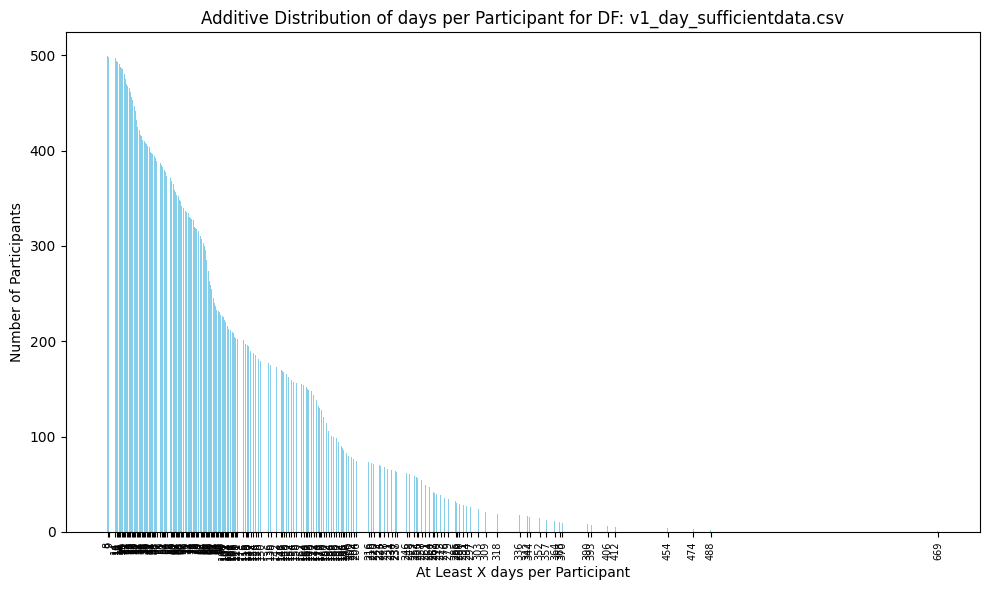

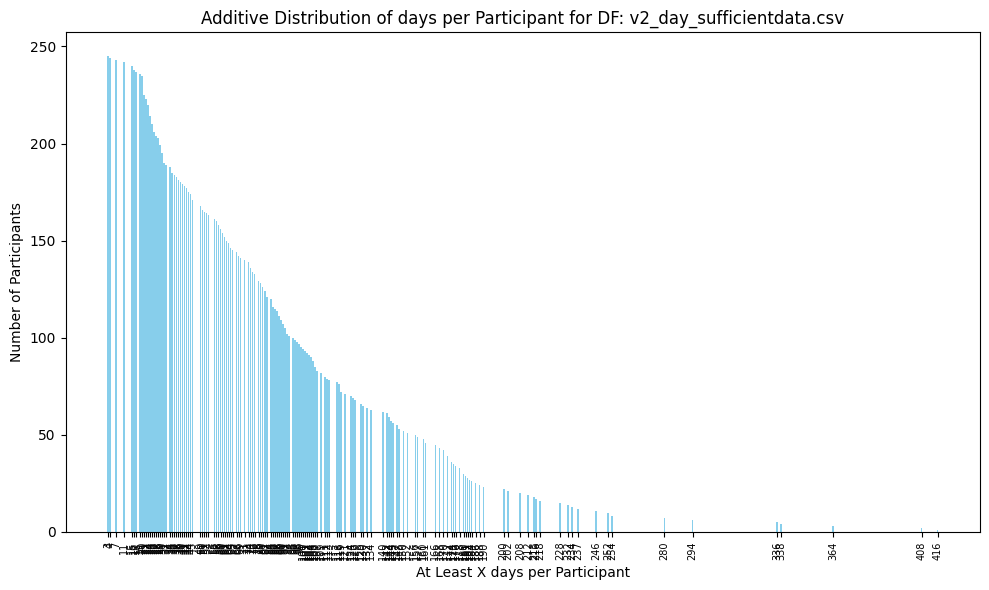

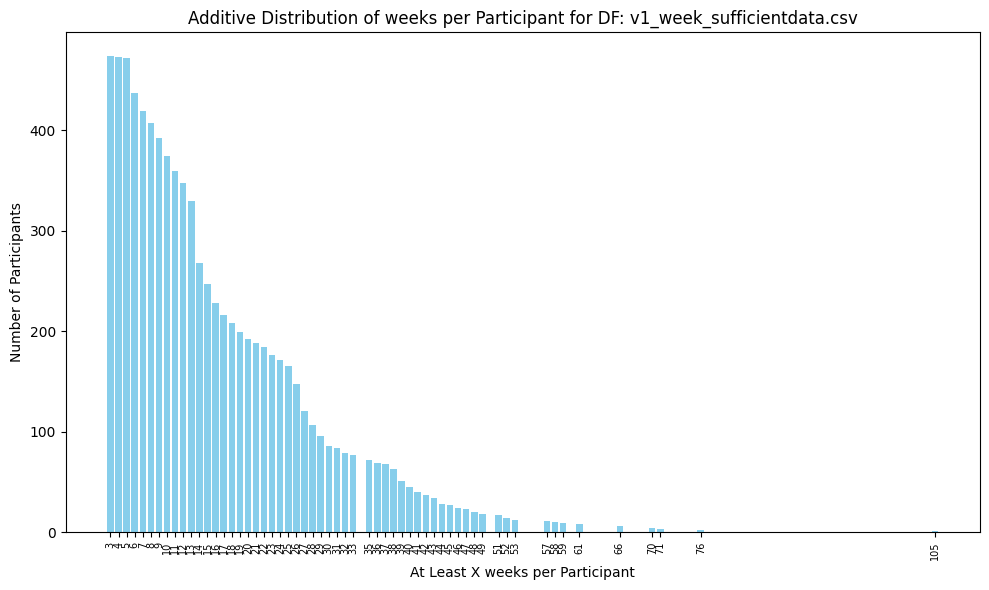

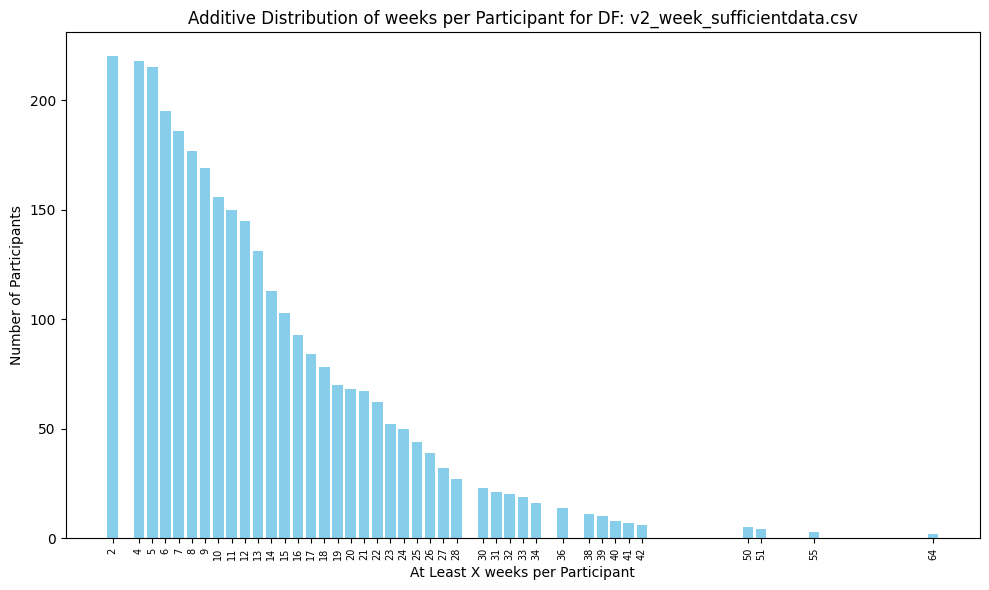

In [6]:
############## Plot-- how many weeks/days does each participant have #############
print(f'Run on: {dt.datetime.today().strftime('%a %d %b %Y, %I:%M%p')}\n')

for name in df_names:
    df = pd.read_csv(os.path.join(brighten_dir, f'{name}_sufficientdata.csv'))
    if 'day' in name:
        time_period='day'
    elif 'week' in name:
         time_period='week'

    vis.plot_participants_per_time(df, time_period=time_period, title=f'{name}_sufficientdata.csv')


### Some columns we can assume 0 values are actually NaN
For example, hours_of_sleep at at 0 actually probably indicates that the sensor wasn't picking up at that time or it was inaccurate. Same goes for hours_walking or distance_walking, since it doesn't make sense for someone to not move at all during the day. If they have very small amounts of walking/activity, that can stay, but a pure 0 means the sensor wasn't active. 

A mobility radius of >0.0015 means that the two farthest points between which a person moved was less than 200ft during a day,  which is unlikely even if they stayed in a small apartment. 
A mobility score of >0.03 means a person moved less than 200ft during a day, which is again unlikely. 

For the per-hour calculations, they are smaller and harder to generalize to real behavior, but if the score is 0 for mobility sensing, then it's fair to say the sensor wasn't representative of real behavior.



In [7]:
#We'll change these columns 0s to NaN
print(f'Run on: {dt.datetime.today().strftime('%a %d %b %Y, %I:%M%p')}\n')

na_thresholds = {
    'mobility_radius': 0.0015,
    'mobility': 0.03,
    'distance_active_hr': 0, 
    'hours_stationary_hr': 0.02, #corresponds to least 30 minutes stationary (cumulative) during the day
    'hours_walking_hr': 0.006,  #corresponds to at least 10minutes walking (cumulative) during the day
    'hours_of_sleep_hr': 0.08 #corresponds to at least 2hrs of sleep during the day
    }

below_thresh = {}
for name in ['v1_day','v2_day', 'v1_week', 'v2_week']:
    print(name)
    df = pd.read_csv(os.path.join(brighten_dir, f'{name}_sufficientdata.csv'))
    df_setNaN = df.copy()
    for col in na_thresholds:
        if col in df_setNaN.columns:
            df_setNaN.loc[df[col] <= na_thresholds[col], col] = np.nan
            below_thresh = df_setNaN[col].loc[df[col] <= na_thresholds[col]].shape[0]
            post_thresh = df_setNaN[col][df[col] <= na_thresholds[col]].sum()
            print(f'For {col}, replaced values <= {na_thresholds[col]} with NaN. Before: {below_thresh}, after: {post_thresh}')
    display(df_setNaN[[col for col in id_columns if col in df_setNaN.columns]+[col for col in df_setNaN.columns if col not in id_columns]].head())
    df_setNaN.to_csv(os.path.join(brighten_dir, f'{name}_setNaN.csv'), index=False)
    print(f"Created {name}_setNaN.csv in brighten_dir")


Run on: Sun 12 Apr 2026, 10:42PM

v1_day
For mobility_radius, replaced values <= 0.0015 with NaN. Before: 1429, after: 0.0
For mobility, replaced values <= 0.03 with NaN. Before: 3076, after: 0.0


/var/folders/hw/bbf5fg0s5md12mjn50bptvhh0000gq/T/ipykernel_46404/962194070.py:16: DtypeWarning: Columns (36,37,48) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(os.path.join(brighten_dir, f'{name}_sufficientdata.csv'))


,num_id,date,month,week,day,id_week,id_day,v,season,day_of_week,...,bin_clin,gender,education,working,income_satisfaction,income_lastyear,marital_status,race,age_category,season_num
0,1.0,2014-08-01,8.0,0,0,BLUE-00049_0,BLUE-00049_0,V1,summer,5.0,...,0.0,1.0,2.0,0.0,3.0,6.0,0.0,2.0,3.0,4.0
1,1.0,2014-08-02,8.0,0,1,BLUE-00049_0,BLUE-00049_1,V1,summer,6.0,...,0.0,1.0,2.0,0.0,3.0,6.0,0.0,2.0,3.0,4.0
2,1.0,2014-08-03,8.0,0,2,BLUE-00049_0,BLUE-00049_2,V1,summer,7.0,...,0.0,1.0,2.0,0.0,3.0,6.0,0.0,2.0,3.0,4.0
3,1.0,2014-08-04,8.0,0,3,BLUE-00049_0,BLUE-00049_3,V1,summer,1.0,...,0.0,1.0,2.0,0.0,3.0,6.0,0.0,2.0,3.0,4.0
4,1.0,2014-08-05,8.0,0,4,BLUE-00049_0,BLUE-00049_4,V1,summer,2.0,...,0.0,1.0,2.0,0.0,3.0,6.0,0.0,2.0,3.0,4.0


Created v1_day_setNaN.csv in brighten_dir
v2_day
For distance_active_hr, replaced values <= 0 with NaN. Before: 2263, after: 0.0
For hours_of_sleep_hr, replaced values <= 0.08 with NaN. Before: 5264, after: 0.0


,num_id,date,month,week,day,id_week,id_day,v,season,day_of_week,...,season_num,distance_walking_hr,hours_active_hr,distance_active_hr,distance_powered_vehicle_hr,hours_high_speed_transportation_hr,hours_of_sleep_hr,distance_high_speed_transportation_hr,hours_powered_vehicle_hr,location_variance_hr
0,153.0,2016-08-13,8.0,0,0,EN00033_0,EN00033_0,V2,summer,6.0,...,4.0,50.590909,0.006091,81.690909,10155.036364,0.001545,0.383364,526.772727,0.195455,-0.103364
1,153.0,2016-08-14,8.0,0,1,EN00033_0,EN00033_1,V2,summer,7.0,...,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,153.0,2016-08-15,8.0,0,2,EN00033_0,EN00033_2,V2,summer,1.0,...,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,153.0,2016-08-16,8.0,0,3,EN00033_0,EN00033_3,V2,summer,2.0,...,4.0,263.558333,0.068083,433.225000,120.066667,0.000000,0.429167,0.000000,0.001417,-0.284417
4,153.0,2016-08-17,8.0,0,4,EN00033_0,EN00033_4,V2,summer,3.0,...,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Created v2_day_setNaN.csv in brighten_dir
v1_week
For mobility_radius, replaced values <= 0.0015 with NaN. Before: 137, after: 0.0
For mobility, replaced values <= 0.03 with NaN. Before: 274, after: 0.0


,num_id,date,month,week,day,id_week,v,season,day_of_week,cohort,...,bin_clin,gender,education,working,income_satisfaction,income_lastyear,marital_status,race,age_category,season_num
0,1.0,2014-08-01,8.0,0,0,BLUE-00049_0,V1,summer,4.0,PST,...,0.0,1.0,2.0,0.0,3.0,6.0,0.0,2.0,3.0,4.0
1,1.0,2014-08-08,8.0,1,7,BLUE-00049_1,V1,summer,4.0,PST,...,0.0,1.0,2.0,0.0,3.0,6.0,0.0,2.0,3.0,4.0
2,1.0,2014-08-15,8.0,2,14,BLUE-00049_2,V1,summer,4.0,PST,...,0.0,1.0,2.0,0.0,3.0,6.0,0.0,2.0,3.0,4.0
3,1.0,2014-08-22,8.0,3,21,BLUE-00049_3,V1,summer,4.0,PST,...,0.0,1.0,2.0,0.0,3.0,6.0,0.0,2.0,3.0,4.0
4,1.0,2014-08-29,8.0,4,28,BLUE-00049_4,V1,summer,6.0,PST,...,0.0,1.0,2.0,0.0,3.0,6.0,0.0,2.0,3.0,4.0


Created v1_week_setNaN.csv in brighten_dir
v2_week
For distance_active_hr, replaced values <= 0 with NaN. Before: 209, after: 0.0
For hours_of_sleep_hr, replaced values <= 0.08 with NaN. Before: 409, after: 0.0


,num_id,date,month,week,day,id_week,v,season,day_of_week,cohort,...,season_num,distance_walking_hr,hours_active_hr,distance_active_hr,distance_powered_vehicle_hr,hours_high_speed_transportation_hr,hours_of_sleep_hr,distance_high_speed_transportation_hr,hours_powered_vehicle_hr,location_variance_hr
0,153.0,2016-08-13,8.000000,0,0,EN00033_0,V2,summer,4.0,NaN,...,4.000000,157.074621,0.037087,257.457955,5137.551515,0.000773,0.406265,263.386364,0.098436,-0.193890
1,153.0,2016-08-20,8.000000,1,7,EN00033_1,V2,summer,4.0,NaN,...,4.000000,543.600609,0.168271,1727.165864,6224.989206,0.000000,0.807474,0.000000,0.111671,-0.201521
2,153.0,2016-08-27,8.285714,2,14,EN00033_2,V2,summer,4.0,NaN,...,3.142857,339.544444,0.081444,670.888889,0.000000,0.000000,0.572222,0.000000,0.000000,-0.410667
3,153.0,2016-09-03,9.000000,3,21,EN00033_3,V2,fall,4.0,NaN,...,1.000000,621.374000,0.188446,2489.018929,18964.589000,0.000425,0.631160,158.615000,0.236189,-0.191066
4,153.0,2016-09-10,9.000000,4,28,EN00033_4,V2,fall,6.0,NaN,...,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Created v2_week_setNaN.csv in brighten_dir


In [8]:
# #Binarize + add indicator cols
# from scripts.variables import daily_v2_phone

# for name in ['v1_day','v2_day', 'v1_week', 'v2_week']:
# 	df = pd.read_csv(os.path.join(brighten_dir, f'{name}_setNaN.csv'))
# 	binarize_cols = [col for col in df.columns if col in ['hours_high_speed_transportation_hr','distance_high_speed_transportation_hr']+daily_v2_phone]
# 	indicator_cols = [col for col in df.columns if col in daily_cols_v1+daily_cols_v2]
# 	for col in binarize_cols:
# 		df[col] = pd.to_numeric(df[col])
# 		# Create binarized
# 		df[f'{col}_bin'] = (df[col] > 0).astype(int)
# 		df[f'{col}_nonzero'] = np.where(df[col].astype(str).str.contains('0'), np.nan, df[col])

# 	for col in indicator_cols:
# 		try:
# 			df[col] = pd.to_numeric(df[col])
# 		except Exception as e:
# 			print(f'Skipping {col}, non-numeric')
# 			continue
# 		# Create binary indigator
# 		df[f'{col}_indicator'] = (df[col] > 0).astype(int)
# 		print(f"Created indicator col for {col}, {col}_indicator:")
# 		print(df[f'{col}_indicator'].value_counts())

 
# 	df[f'phq2_indicator'] = df['phq2_sum'].isnull().astype(int)
    
# 	print(f"Final cols df: {df.columns.to_list()}")
# 	df.to_csv(os.path.join(brighten_dir, f'{name}_binarized.csv'))
# 	display(df[id_columns+[col for col in df.columns if col not in id_columns]].head())
# 	print(f"Saved {name} to {name}_binarized.csv")
    

## Testing different combinations of rows for # subjects with sufficient data

# This is too computationally costly
 maybe try with categories and having one col from each category
 for now just using filtering


In [9]:

# import itertools
# import plotly.express as px 
# def optimize_people_vs_columns(df, group_col, feature_cols, coverage_threshold=0.7):
# 	results = []
    
# 	for k in range(len(feature_cols), 3, -1):

# 		for col_subset in itertools.combinations(feature_cols, k):
# 			#print(col_subset)
# 			# For each group (person), what % of the selected columns are non-missing?
# 			group_coverage = (
# 				df.groupby(group_col)[list(col_subset)]
# 				.apply(lambda x: x.notna().mean(axis=1).mean())  # overall coverage per person
# 			)
# 			keep_ids = group_coverage[group_coverage >= coverage_threshold].index
# 			filtered_df = df[df[group_col].isin(keep_ids)]
# 			results.append({
# 				'num_columns': k,
# 				'columns': [col_subset],
# 				'num_people': len(keep_ids),
# 				'df': filtered_df
# 			})

# 	# Choose best tradeoff (e.g., most people, or most data points)
# 	best = max(results, key=lambda x: x['num_people'] * x['num_columns'])
# 	print(f'For {name}, best = num_columns {best['num_columns']}, num_people {best['num_people']}, columns = {best['columns']}')

# 	return best, results


# all_results = {}
# for name in ['v1_day','v2_day', 'v1_week', 'v2_week']:
# 	data_df = pd.read_csv(os.path.join(brighten_dir, f'{name}_binarized.csv'))
# 	best, results = optimize_people_vs_columns(
# 		data_df,
# 		group_col='num_id',
# 		feature_cols=[col for col in daily_cols_v1+daily_cols_v2 if col in data_df.columns.tolist()],
# 		coverage_threshold=0.7
# 	)

# 	all_results[name] = results



In [10]:
# For now we'll just keep based on coverage threshold
coverage_threshold=0.7
print(f'Run on: {dt.datetime.today().strftime('%a %d %b %Y, %I:%M%p')}\n')

results=[]
for v in ['v1', 'v2']:
    for time in ['day', 'week']:
        print(f"\n=== Processing: {v} {time} ===")
        df = pd.read_csv(os.path.join(brighten_dir, f'{v}_{time}_setNaN.csv'))
        df = df.loc[:, ~df.columns.str.contains(r"^Unnamed")]
        df_filtered_byDay = df.loc[df['day']<85]
        print(f'Subs in df_filtered_byDay: {df_filtered_byDay['num_id'].nunique()}')

        sensor_columns = daily_cols_v1 if v == 'v1' else daily_v2_sensor_hr+daily_v2_weather

        grouped = df_filtered_byDay.groupby('num_id')[sensor_columns].apply(lambda x: x.notna().mean(axis=1).mean())
        keep_ids = grouped[grouped >= coverage_threshold].index
        filtered_df = df_filtered_byDay[df_filtered_byDay['num_id'].isin(keep_ids)]
        filtered_df = filtered_df.drop(columns=[col for col in filtered_df.columns if col in daily_v2_phone])
        print(f'Subs in df_filtered_byCoverage: {filtered_df['num_id'].nunique()}')
        filtered_df.to_csv(os.path.join(brighten_dir, f'{v}_{time}_filtered.csv'), index=False)
        print(f'Saved df to {v}_{time}_filtered.csv')



Run on: Sun 12 Apr 2026, 10:42PM


=== Processing: v1 day ===


/var/folders/hw/bbf5fg0s5md12mjn50bptvhh0000gq/T/ipykernel_46404/815869755.py:9: DtypeWarning: Columns (36,37,48) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(os.path.join(brighten_dir, f'{v}_{time}_setNaN.csv'))


Subs in df_filtered_byDay: 499
Subs in df_filtered_byCoverage: 223
Saved df to v1_day_filtered.csv

=== Processing: v1 week ===
Subs in df_filtered_byDay: 474
Subs in df_filtered_byCoverage: 212
Saved df to v1_week_filtered.csv

=== Processing: v2 day ===
Subs in df_filtered_byDay: 245
Subs in df_filtered_byCoverage: 190
Saved df to v2_day_filtered.csv

=== Processing: v2 week ===
Subs in df_filtered_byDay: 220
Subs in df_filtered_byCoverage: 174
Saved df to v2_week_filtered.csv


In [11]:
for name in df_names:
    df = pd.read_csv(os.path.join(brighten_dir, f'{name}_filtered.csv'), low_memory=False)
    baseline_cols_present = [col for col in df.columns if col in baseline_cols]
    df[baseline_cols_present] = (
        df.groupby("num_id")[baseline_cols_present]
        .apply(lambda g: g.ffill().bfill())
        .reset_index(drop=True)
    )
    df.to_csv(os.path.join(brighten_dir, f'{name}_baseFilled.csv'))


for name in df_names:
    df = pd.read_csv(os.path.join(brighten_dir, f'{name}_baseFilled.csv'), low_memory=False)
    weekly_cols_present = [col for col in df.columns if col in weekly_cols]
    df[weekly_cols_present] = (
        df.groupby("id_week")[weekly_cols_present]
        .apply(lambda g: g.ffill().bfill())
        .reset_index(drop=True)
    )
    df.to_csv(os.path.join(brighten_dir, f'{name}_weekFilled.csv'), index=False)


# Train test val split

In [12]:
from sklearn.model_selection import GroupShuffleSplit
print(f'Run on: {dt.datetime.today().strftime('%a %d %b %Y, %I:%M%p')}\n')


for name in ['v1_day','v2_day', 'v1_week', 'v2_week']:
    data_df = pd.read_csv(os.path.join(brighten_dir, f'{name}_weekFilled.csv'))
    gss = GroupShuffleSplit(n_splits=1, test_size=0.15, random_state=42)
    groups = data_df['num_id'] # groups variable is based on num_id, so that no subjects are in train and test etc, 
    trainval_idx, test_idx = next(gss.split(data_df, groups=groups))
    
    # Get train/test sets
    trainval, test = data_df.iloc[trainval_idx], data_df.iloc[test_idx]
    trainval = trainval.loc[:, ~trainval.columns.str.contains('^Unnamed')]
    trainval.to_csv(os.path.join(brighten_dir, f'{name}_trainval.csv'), index=False)
    print('trainval',name, trainval.columns.to_list())
    test = test.loc[:, ~test.columns.str.contains('^Unnamed')]
    test.to_csv(os.path.join(brighten_dir, f'{name}_test.csv'), index=False)
    print('test    ',name, test.columns.to_list(),'\n')


Run on: Sun 12 Apr 2026, 10:43PM

trainval v1_day ['day', 'date', 'participant_id', 'week', 'phq9_sum', 'phq9_1', 'phq9_2', 'phq9_3', 'phq9_4', 'phq9_5', 'phq9_6', 'phq9_7', 'phq9_8', 'phq9_9', 'v', 'phq9_cat', 'phq9_bin', 'dt_phq9', 'phq2_1', 'phq2_2', 'phq2_sum', 'phq2_bin', 'dt_phq2', 'sds_1', 'sds_2', 'sds_3', 'stress', 'support', 'dt_sds', 'sleep_1', 'sleep_2', 'sleep_3', 'dt_sleep', 'mood_1', 'dt_gic', 'cohort', 'user_phone_type', 'aggregate_communication', 'call_count', 'call_duration', 'interaction_diversity', 'missed_interactions', 'mobility', 'mobility_radius', 'sms_count', 'sms_length', 'unreturned_calls', 'dt_phone_v1', 'dt_phone_v2', 'dt_weather_v2', 'hours_accounted_for', 'hours_stationary', 'hours_stationary_nhw', 'hours_walking', 'dt_mobility_v2', 'phq9_1_base', 'phq9_2_base', 'phq9_3_base', 'phq9_4_base', 'phq9_5_base', 'phq9_6_base', 'phq9_7_base', 'phq9_8_base', 'phq9_9_base', 'screen_1', 'screen_2', 'screen_3', 'screen_4', 'phq9_category', 'bin_clin', 'gender', 'edu